# VAE Easy Task: Hybrid English + Bangla Clustering

Pipeline:
1. Download FMA Small metadata (pre-extracted librosa features)
2. Simulate Bangla music features (genre-realistic Gaussian distributions)
3. Merge English + Bangla into a hybrid dataset
4. Train a standard MLP-VAE
5. Cluster latent space with K-Means
6. Compare against PCA + K-Means baseline
7. Visualise with t-SNE and UMAP
8. Report Silhouette Score and Calinski-Harabasz Index

## 0. Setup

In [27]:
import sys
from pathlib import Path
PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

Project root: /Users/israt/Codes/VAE-music


In [28]:
import warnings
import numpy as np
import pandas as pd
import torch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

import umap as umap_lib

from config.config import (
    BATCH_SIZE, BETA_DEFAULT, EPOCHS, FMA_METADATA_URL,
    HIDDEN_DIMS, KMEANS_NINIT, LANG_COLORS, LANG_MARKERS,
    LATENT_DIM, LR, NUMPY_SEED, TORCH_SEED,
)
from src.data.fma import download_fma_metadata, load_fma
from src.models.mlp_vae import MLPVAE
from src.training.trainer import extract_latent, train_model
from src.clustering.engine import elbow_analysis
from src.visualization.plots import (
    plot_cluster_composition,
    plot_dataset_distribution,
    plot_elbow,
    plot_language_separation,
    plot_metrics_comparison,
    plot_training_curves,
    plot_tsne_umap,
)
from scripts.run_easy import simulate_bangla_features

warnings.filterwarnings("ignore")
np.random.seed(NUMPY_SEED)
torch.manual_seed(TORCH_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS = PROJECT_ROOT / "results" / "easy"
RESULTS.mkdir(parents=True, exist_ok=True)
print("Device:", DEVICE)

Device: cpu


## 1. Download FMA Dataset

In [29]:
FMA_DIR = PROJECT_ROOT / "data" / "fma" / "fma_metadata"
download_fma_metadata(FMA_DIR, FMA_METADATA_URL)

  [FMA] Metadata already present at /Users/israt/Codes/VAE-music/data/fma/fma_metadata


## 2. Load Data + Simulate Bangla Features

  [FMA] Loaded: (10000, 57) | Genres: ['Blues', 'Classical', 'Country', 'Easy Listening', 'Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Jazz', 'Old-Time / Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']
  Bangla: (100, 57) | Genres: ['Baul', 'Classical', 'Folk', 'ModernPop', 'Rabindra']
  Merged: (10100, 57) | Genres=19
  English: 10000 | Bangla: 100
  Saved: /Users/israt/Codes/VAE-music/results/easy/dataset_distribution.png


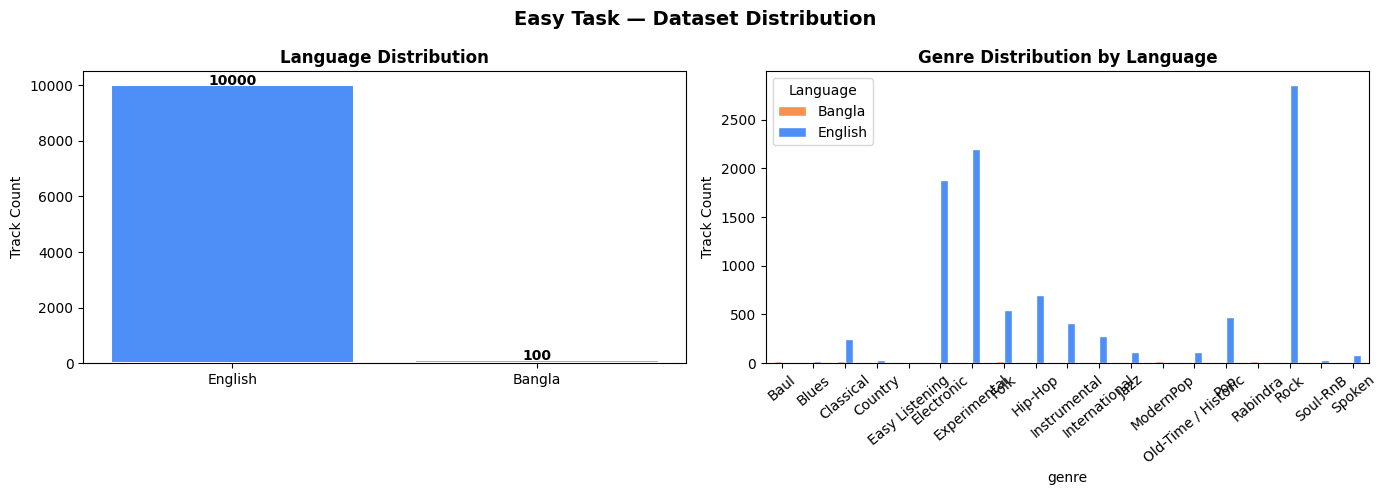

In [30]:
X_en, y_en = load_fma(FMA_DIR)
lang_en = np.array(["English"] * len(X_en))
X_en = np.nan_to_num(X_en, nan=0.0, posinf=0.0, neginf=0.0)

en_mean = X_en.mean(axis=0)
en_std = X_en.std(axis=0) + 1e-8
X_bn, y_bn, lang_bn = simulate_bangla_features(en_mean, en_std)
print(f"  Bangla: {X_bn.shape} | Genres: {np.unique(y_bn).tolist()}")

X_raw = np.vstack([X_en, X_bn])
y_labels = np.concatenate([y_en, y_bn])
lang_labels = np.concatenate([lang_en, lang_bn])
X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

le_genre = LabelEncoder()
y_genre = le_genre.fit_transform(y_labels)
le_lang = LabelEncoder()
y_lang = le_lang.fit_transform(lang_labels)
K = len(le_genre.classes_)

print(f"  Merged: {X_scaled.shape} | Genres={K}")
print(f"  English: {(lang_labels == 'English').sum()} | Bangla: {(lang_labels == 'Bangla').sum()}")

plot_dataset_distribution(
    y_labels, lang_labels,
    title="Easy Task — Dataset Distribution",
    save_path=RESULTS / "dataset_distribution.png",
)

## 3. Train MLP-VAE

    Epoch   1/100  loss=54.1285
    Epoch  25/100  loss=34.5068
    Epoch  50/100  loss=33.8458
    Epoch  75/100  loss=33.4228
    Epoch 100/100  loss=33.4396
Best loss: 33.3214
  Saved: /Users/israt/Codes/VAE-music/results/easy/training_curves.png


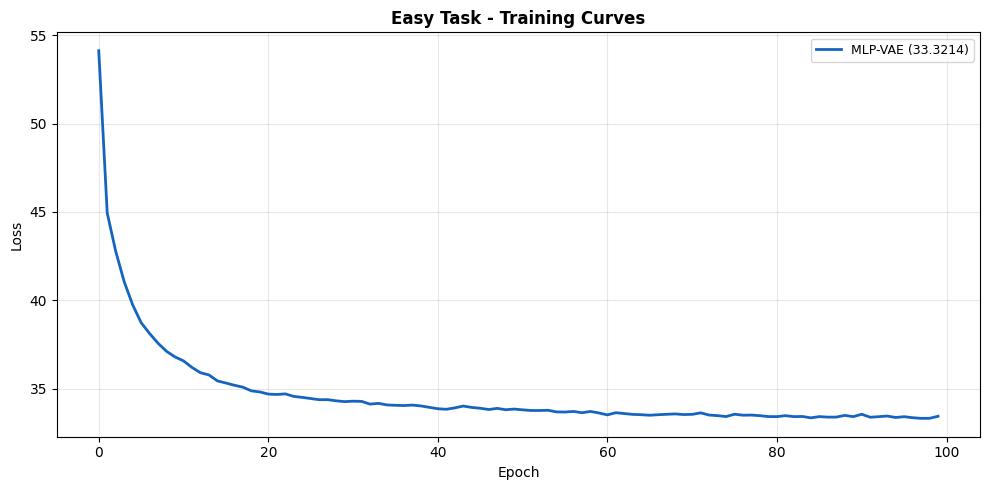

In [31]:
model = MLPVAE(X_scaled.shape[1], LATENT_DIM, h=HIDDEN_DIMS)
model, history, best_loss = train_model(
    X_scaled, model,
    model_type="vae", beta=BETA_DEFAULT,
    epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE,
    device=DEVICE, verbose=True,
)
print(f"Best loss: {best_loss:.4f}")

plot_training_curves(
    histories={"MLP-VAE": history},
    losses={"MLP-VAE": best_loss},
    model_colors={"MLP-VAE": "#1565C0"},
    title="Easy Task - Training Curves",
    save_path=RESULTS / "training_curves.png",
)

## 4. Extract Latent Representations

In [32]:
Z = extract_latent(model, X_scaled, device=DEVICE)
np.save(RESULTS / "latent_Z.npy", Z)
print(f"Latent shape: {Z.shape}")

Latent shape: (10100, 32)


## 5. Elbow Analysis

  Saved: /Users/israt/Codes/VAE-music/results/easy/elbow_method.png


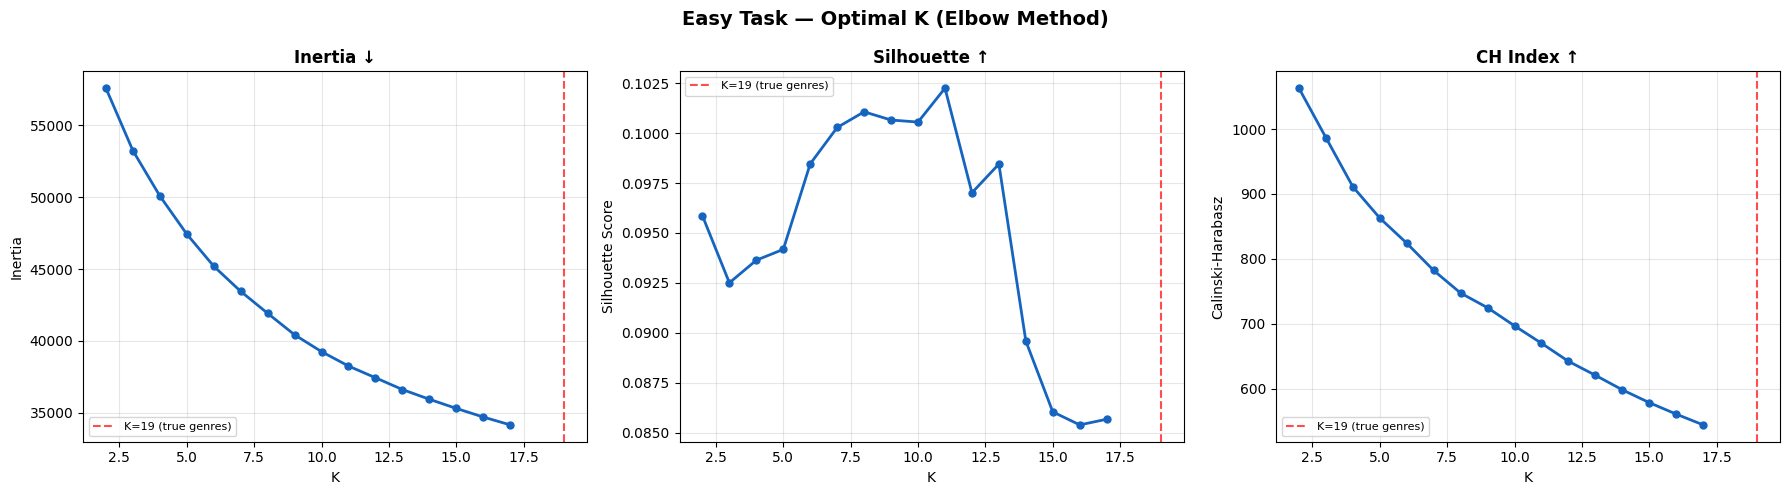

In [33]:
elbow = elbow_analysis(Z, k_range=range(2, 18))
plot_elbow(
    elbow, true_k=K,
    title="Easy Task — Optimal K (Elbow Method)",
    save_path=RESULTS / "elbow_method.png",
)

## 6. K-Means Clustering - VAE vs PCA Baseline

In [34]:
km_vae = KMeans(n_clusters=K, n_init=KMEANS_NINIT, random_state=42)
labels_vae = km_vae.fit_predict(Z)

pca = PCA(n_components=LATENT_DIM, random_state=42)
Z_pca = pca.fit_transform(X_scaled)
km_pca = KMeans(n_clusters=K, n_init=KMEANS_NINIT, random_state=42)
labels_pca = km_pca.fit_predict(Z_pca)

print(f"VAE cluster sizes: {np.bincount(labels_vae).tolist()}")
print(f"PCA explained variance ({LATENT_DIM} components): {pca.explained_variance_ratio_.sum():.2%}")

VAE cluster sizes: [375, 630, 406, 639, 678, 285, 515, 437, 474, 1021, 571, 644, 339, 716, 500, 407, 448, 811, 204]
PCA explained variance (32 components): 93.06%


## 7. Visualisation - t-SNE and UMAP

Running t-SNE...
  Saved: /Users/israt/Codes/VAE-music/results/easy/tsne_visualization.png


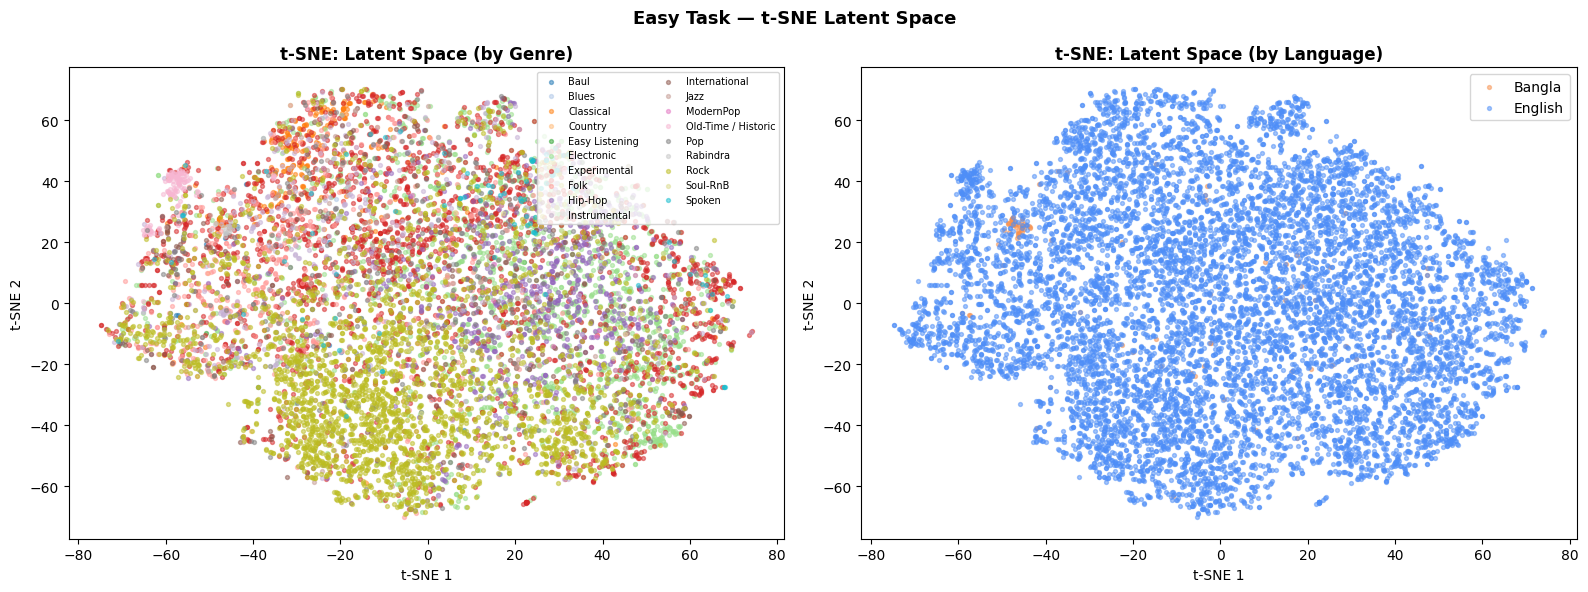

Running UMAP...
  Saved: /Users/israt/Codes/VAE-music/results/easy/umap_visualization.png


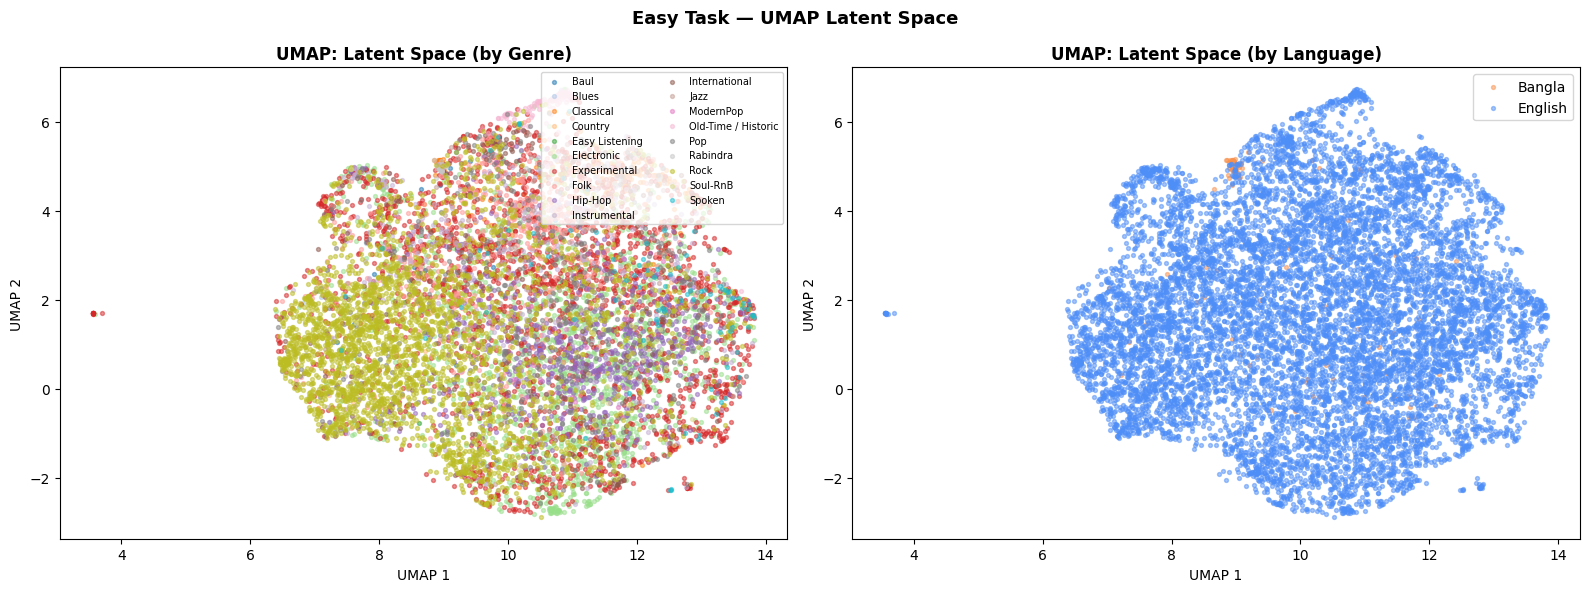

In [35]:
print("Running t-SNE...")
Z_tsne = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42).fit_transform(Z)
plot_tsne_umap(
    Z_tsne, y_genre, y_lang, list(le_genre.classes_), list(le_lang.classes_),
    projection="t-SNE",
    title="Easy Task — t-SNE Latent Space",
    save_path=RESULTS / "tsne_visualization.png",
)

print("Running UMAP...")
Z_umap = umap_lib.UMAP(n_components=2, n_neighbors=20, min_dist=0.1, random_state=42).fit_transform(Z)
plot_tsne_umap(
    Z_umap, y_genre, y_lang, list(le_genre.classes_), list(le_lang.classes_),
    projection="UMAP",
    title="Easy Task — UMAP Latent Space",
    save_path=RESULTS / "umap_visualization.png",
)

## 8. Evaluation Metrics

  Saved: /Users/israt/Codes/VAE-music/results/easy/metrics_comparison.png


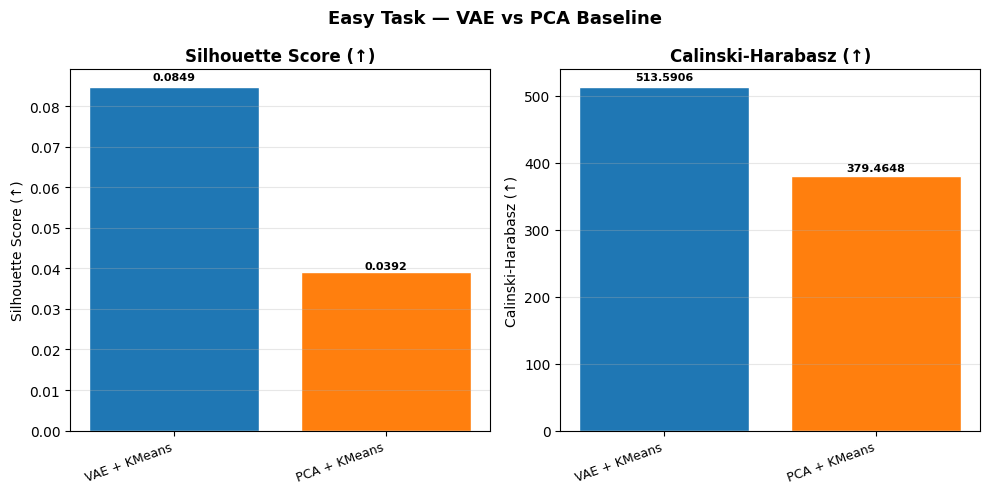

  Saved: /Users/israt/Codes/VAE-music/results/easy/cluster_composition.png


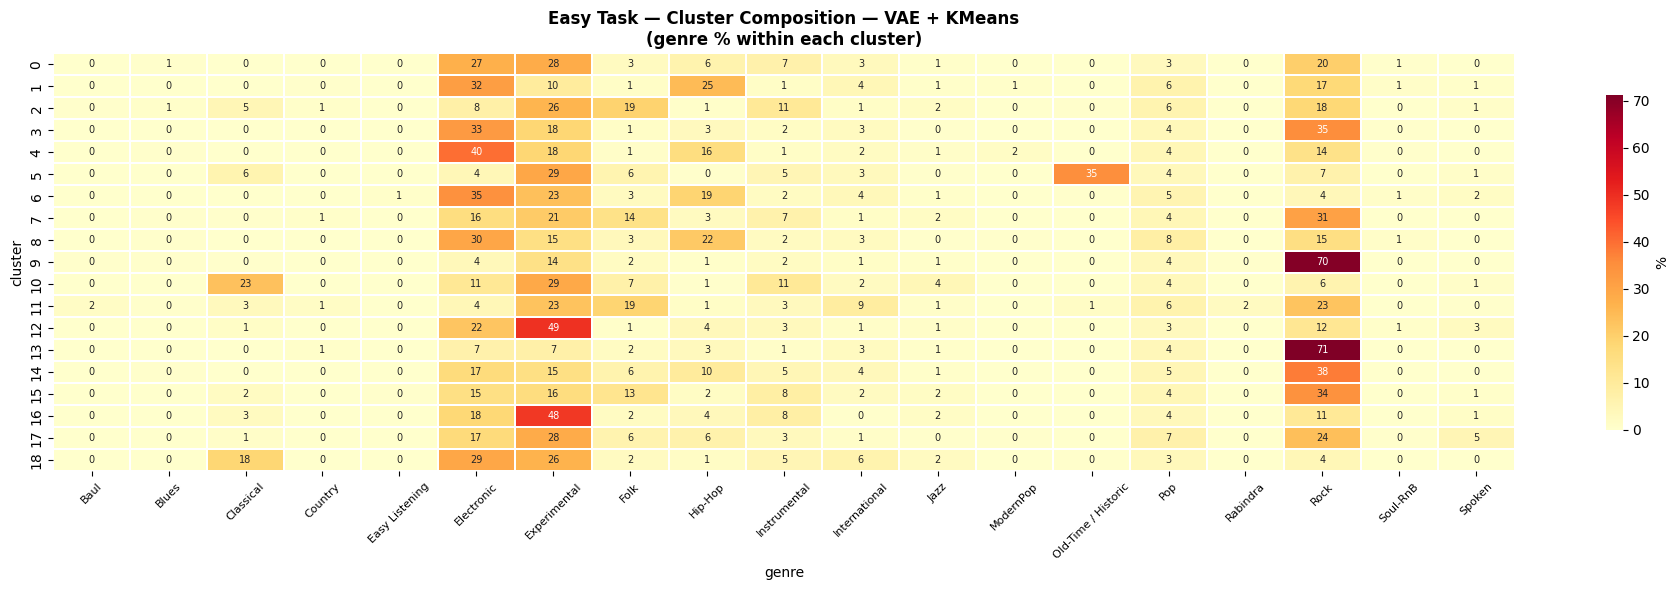

  Saved: /Users/israt/Codes/VAE-music/results/easy/language_separation.png


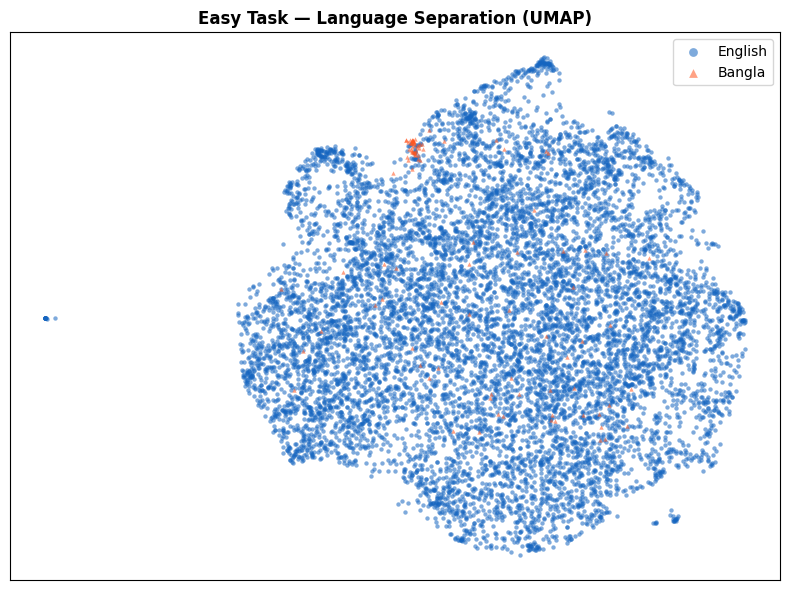

In [36]:
sil_vae = silhouette_score(Z, labels_vae)
sil_pca = silhouette_score(Z_pca, labels_pca)
ch_vae = calinski_harabasz_score(Z, labels_vae)
ch_pca = calinski_harabasz_score(Z_pca, labels_pca)

plot_metrics_comparison(
    metrics_dict={
        "VAE + KMeans": {"Silhouette": sil_vae, "Calinski-H": ch_vae},
        "PCA + KMeans": {"Silhouette": sil_pca, "Calinski-H": ch_pca},
    },
    metric_keys=["Silhouette", "Calinski-H"],
    metric_labels=["Silhouette Score (\u2191)", "Calinski-Harabasz (\u2191)"],
    title="Easy Task — VAE vs PCA Baseline",
    save_path=RESULTS / "metrics_comparison.png",
)

plot_cluster_composition(
    labels_vae, y_labels,
    model_name="VAE + KMeans",
    title="Easy Task — Cluster Composition",
    save_path=RESULTS / "cluster_composition.png",
)

plot_language_separation(
    Z_umap, lang_labels, LANG_COLORS, LANG_MARKERS,
    title="Easy Task — Language Separation (UMAP)",
    save_path=RESULTS / "language_separation.png",
)

## 9. Save Results

In [37]:
pd.DataFrame({
    "genre": y_labels, "language": lang_labels,
    "cluster_vae": labels_vae, "cluster_pca": labels_pca,
}).to_csv(RESULTS / "cluster_assignments.csv", index=False)

pd.DataFrame({
    "Method": ["VAE + KMeans", "PCA + KMeans"],
    "Silhouette Score": [round(sil_vae, 4), round(sil_pca, 4)],
    "Calinski-Harabasz": [round(ch_vae, 2),  round(ch_pca, 2)],
}).to_csv(RESULTS / "metrics_table.csv", index=False)

torch.save(
    {
        "model_state": model.state_dict(),
        "config": {
            "input_dim": X_scaled.shape[1],
            "hidden_dims": HIDDEN_DIMS,
            "latent_dim": LATENT_DIM,
            "beta": BETA_DEFAULT,
        },
    },
    RESULTS / "vae_easy_model.pt",
)

winner_sil = "VAE" if sil_vae > sil_pca else "PCA"
winner_ch = "VAE" if ch_vae  > ch_pca  else "PCA"
sep = "=" * 60
print(sep)
print("  EASY TASK — FINAL REPORT")
print(sep)
print(f"  Dataset   : {len(y_labels)} tracks ({(lang_labels == 'English').sum()} EN + {(lang_labels == 'Bangla').sum()} BN)")
print(f"  Features  : {X_scaled.shape[1]} dims | Genres: {K}")
print(f"  Latent dim: {LATENT_DIM} | Best loss: {best_loss:.4f}")
print()
print(f"  {'Method':<20} {'Silhouette':>12} {'Calinski-H':>12}")
print(f"  {'-'*46}")
print(f"  {'VAE + KMeans':<20} {sil_vae:>12.4f} {ch_vae:>12.1f}")
print(f"  {'PCA + KMeans':<20} {sil_pca:>12.4f} {ch_pca:>12.1f}")
print()
print(f"  Winner (Silhouette) : {winner_sil}")
print(f"  Winner (CH Index)   : {winner_ch}")
print(f"\n  Results saved to: {RESULTS}")
print(sep)

  EASY TASK — FINAL REPORT
  Dataset   : 10100 tracks (10000 EN + 100 BN)
  Features  : 57 dims | Genres: 19
  Latent dim: 32 | Best loss: 33.3214

  Method                 Silhouette   Calinski-H
  ----------------------------------------------
  VAE + KMeans               0.0849        513.6
  PCA + KMeans               0.0392        379.5

  Winner (Silhouette) : VAE
  Winner (CH Index)   : VAE

  Results saved to: /Users/israt/Codes/VAE-music/results/easy
